# Financial Analysis of Congressional Stock Trades
This notebook will use `yfinance` to fetch historical stock data and calculate returns for the traded stocks.

In [1]:
import pandas as pd
import yfinance as yf
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from concurrent.futures import ThreadPoolExecutor

df = pd.read_csv('../data/legislative_trades.csv')
df['transaction_date'] = pd.to_datetime(df['transaction_date'])

# Filter only valid tickers (single words without spaces or weird chars)
df = df[df['ticker'].notna()]
financial_df = df[df['ticker'].str.match(r'^[A-Z]{1,5}$')]

print(f"Total valid stock trades: {len(financial_df)}")
financial_df.head()

Total valid stock trades: 12315


,chamber,legislator_name,transaction_date,disclosure_date,ticker,asset_description,asset_type,transaction_type,amount_range,amount_min,amount_max,amount_avg,owner,ptr_link,office,party,state,transaction_year,disclosure_year,comment
0,Senate,Ron L Wyden,2020-11-10,NaN,BYND,"Beyond Meat, Inc.",Stock,Sale,"$50,001 - $100,000",50001.0,100000.0,75000.5,Spouse,https://efdsearch.senate.gov/search/view/ptr/a...,NaN,NaN,NaN,2020,NaN,--
1,Senate,Pat Roberts,2020-11-16,NaN,BA,The Boeing Company,Stock,Purchase,"$15,001 - $50,000",15001.0,50000.0,32500.5,Spouse,https://efdsearch.senate.gov/search/view/ptr/b...,NaN,NaN,NaN,2020,NaN,R
2,Senate,Pat Roberts,2020-11-16,NaN,V,Visa Inc.,Stock,Purchase,"$15,001 - $50,000",15001.0,50000.0,32500.5,Spouse,https://efdsearch.senate.gov/search/view/ptr/b...,NaN,NaN,NaN,2020,NaN,555
3,Senate,Pat Roberts,2020-11-24,NaN,COST,Costco Wholesale Corporation,Stock,Purchase,"$15,001 - $50,000",15001.0,50000.0,32500.5,Spouse,https://efdsearch.senate.gov/search/view/ptr/b...,NaN,NaN,NaN,2020,NaN,555
4,Senate,Pat Roberts,2020-11-04,NaN,COST,Costco Wholesale Corporation,Stock,Sale,"$15,001 - $50,000",15001.0,50000.0,32500.5,Spouse,https://efdsearch.senate.gov/search/view/ptr/b...,NaN,NaN,NaN,2020,NaN,555


In [2]:
def fetch_ticker_data(tickers):
    print(f"Fetching data for {len(tickers)} tickers...")
    # Fetch historical data spanning the trades (plus buffer for forward looking ROI)
    # Since our trades range from 2021-2024 (adjust as needed), we get a wide pull
    start_date = financial_df['transaction_date'].min() - pd.Timedelta(days=30)
    end_date = financial_df['transaction_date'].max() + pd.Timedelta(days=180) 
    
    # Download in bulk for efficiency
    raw_data = yf.download(list(tickers), start=start_date, end=end_date, interval='1d', group_by='ticker', threads=True)
    return raw_data

unique_tickers = financial_df['ticker'].unique()
# Let's get top 50 mostly traded tickers to prevent massive API overhead for now
top_tickers = financial_df['ticker'].value_counts().head(50).index.tolist()

market_data = fetch_ticker_data(top_tickers)
if market_data is not None:
    print("\nFetched market data shape:", market_data.shape)
else:
    print("\nFailed to fetch market data.")

Fetching data for 50 tickers...


[*********************100%***********************]  50 of 50 completed



Fetched market data shape: (2763, 250)


In [3]:
def calculate_returns(row, market_matrix):
    ticker = row['ticker']
    t_date = row['transaction_date']
    
    if ticker not in market_matrix:
        return pd.Series([np.nan, np.nan, np.nan])
    
    ticker_df = market_matrix[ticker]
    
    # We need the close price on or closely after the transaction date
    history = ticker_df['Close'].dropna()
    valid_dates = history.index[history.index >= t_date]
    
    if len(valid_dates) == 0:
        return pd.Series([np.nan, np.nan, np.nan])
        
    start_price = history.loc[valid_dates[0]]
    
    # Find dates near 30, 90, 180 days out
    d30 = history.index[history.index >= (t_date + pd.Timedelta(days=30))]
    d90 = history.index[history.index >= (t_date + pd.Timedelta(days=90))]
    d180 = history.index[history.index >= (t_date + pd.Timedelta(days=180))]
    
    r30 = (history.loc[d30[0]] - start_price) / start_price if len(d30) > 0 else np.nan
    r90 = (history.loc[d90[0]] - start_price) / start_price if len(d90) > 0 else np.nan
    r180 = (history.loc[d180[0]] - start_price) / start_price if len(d180) > 0 else np.nan
    
    return pd.Series({'roi_30d': r30, 'roi_90d': r90, 'roi_180d': r180})

# Apply only to trades in top 50 tickers
top_trades_df = financial_df[financial_df['ticker'].isin(top_tickers)].copy()
top_trades_df[['roi_30d', 'roi_90d', 'roi_180d']] = top_trades_df.apply(lambda row: calculate_returns(row, market_data), axis=1)

print("Return calculation complete.")
top_trades_df[['ticker', 'transaction_date', 'transaction_type', 'roi_30d', 'roi_90d', 'roi_180d']].head(10)

Return calculation complete.


,ticker,transaction_date,transaction_type,roi_30d,roi_90d,roi_180d
1,BA,2020-11-16,Purchase,0.115959,0.073024,0.126383
2,V,2020-11-16,Purchase,-0.020827,-0.021050,0.067799
3,COST,2020-11-24,Purchase,-0.026262,-0.062795,0.028357
4,COST,2020-11-04,Sale,0.018719,-0.029976,0.039051
5,BA,2020-11-09,Sale,0.293822,0.181702,0.298673
7,NVDA,2020-11-04,Sale,-0.016818,-0.016927,0.076264
11,DIS,2020-11-10,Purchase,0.088523,0.336992,0.296883
18,V,2020-11-20,Purchase,0.025162,0.028424,0.104892
70,AAPL,2020-11-20,Sale,0.092807,0.107072,0.066034
74,TMO,2020-11-20,Purchase,0.026730,0.084223,0.014161


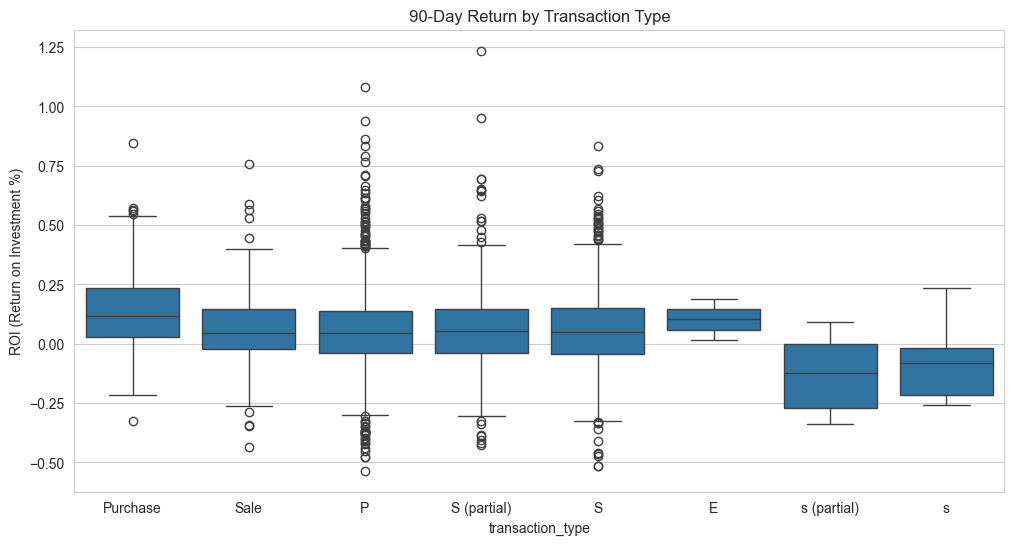

,roi_30d,roi_90d,roi_180d
transaction_type,,,
E,-0.38%,10.26%,25.49%
P,2.12%,5.69%,11.78%
Purchase,4.69%,13.74%,23.88%
S,1.85%,5.77%,12.45%
S (partial),2.05%,6.70%,13.40%
Sale,-0.54%,6.87%,18.97%
s,-0.48%,-7.37%,-5.38%
s (partial),-6.38%,-13.18%,-11.67%


In [4]:
sns.set_style('whitegrid')
plt.figure(figsize=(12, 6))

sns.boxplot(data=top_trades_df, x='transaction_type', y='roi_90d')
plt.title('90-Day Return by Transaction Type')
plt.ylabel('ROI (Return on Investment %)')
plt.show()

avg_returns = top_trades_df.groupby('transaction_type')[['roi_30d', 'roi_90d', 'roi_180d']].mean() * 100
avg_returns.round(2).style.format("{:.2f}%").background_gradient(cmap='RdYlGn')

## 1. Benchmark Against the Market (S&P 500)
Let's see if they are actually beating the overall market return by calculating the "Alpha".

In [5]:
# Fetch S&P 500 ETF (SPY) data for the same time period
spy_start = top_trades_df['transaction_date'].min() - pd.Timedelta(days=30)
spy_end = top_trades_df['transaction_date'].max() + pd.Timedelta(days=180)
spy_data = yf.download('SPY', start=spy_start, end=spy_end, interval='1d')

def calculate_spy_returns(t_date):
    if spy_data is None or spy_data.empty:
        return pd.Series({'spy_30d': np.nan, 'spy_90d': np.nan, 'spy_180d': np.nan})
        
    history = spy_data['Close'].dropna()
    valid_dates = history.index[history.index >= t_date]
    if len(valid_dates) == 0:
        return pd.Series({'spy_30d': np.nan, 'spy_90d': np.nan, 'spy_180d': np.nan})
    
    start_price = history.loc[valid_dates[0]]
    if isinstance(start_price, pd.Series): start_price = start_price.iloc[0]
    
    d30 = history.index[history.index >= (t_date + pd.Timedelta(days=30))]
    d90 = history.index[history.index >= (t_date + pd.Timedelta(days=90))]
    d180 = history.index[history.index >= (t_date + pd.Timedelta(days=180))]
    
    r30 = ((history.loc[d30[0]] - start_price) / start_price).item() if len(d30) > 0 else np.nan
    r90 = ((history.loc[d90[0]] - start_price) / start_price).item() if len(d90) > 0 else np.nan
    r180 = ((history.loc[d180[0]] - start_price) / start_price).item() if len(d180) > 0 else np.nan
    
    return pd.Series({'spy_30d': r30, 'spy_90d': r90, 'spy_180d': r180})

# Apply SPY returns
top_trades_df[['spy_30d', 'spy_90d', 'spy_180d']] = top_trades_df['transaction_date'].apply(calculate_spy_returns)

# Calculate Alpha (Excess Return vs Market)
top_trades_df['alpha_30d'] = top_trades_df['roi_30d'] - top_trades_df['spy_30d']
top_trades_df['alpha_90d'] = top_trades_df['roi_90d'] - top_trades_df['spy_90d']
top_trades_df['alpha_180d'] = top_trades_df['roi_180d'] - top_trades_df['spy_180d']

print("Average Alpha by Transaction Type (in %):")
avg_alpha = top_trades_df.groupby('transaction_type')[['alpha_30d', 'alpha_90d', 'alpha_180d']].mean() * 100
avg_alpha.round(2)

[*********************100%***********************]  1 of 1 completed


Average Alpha by Transaction Type (in %):


,alpha_30d,alpha_90d,alpha_180d
transaction_type,,,
E,-4.28,1.70,7.29
P,0.16,0.77,1.51
Purchase,1.45,2.58,2.50
S,0.03,0.15,0.82
S (partial),0.73,1.80,3.11
Sale,-0.07,-1.67,-0.96
s,-3.72,-1.52,-12.18
s (partial),-3.86,-12.75,-22.87


## 2. Identify the "Best" Traders (Purchases)
Who makes the best purchasing decisions relative to the S&P 500? This leaderboard groups the alpha to see who consistently beats the market when buying stocks.

In [6]:
# Filter only for purchase transactions
purchases = top_trades_df[top_trades_df['transaction_type'].str.contains('Purchase|buy', case=False, na=False)]

# Group by Legislator to calculate average alpha and trade count
leaderboard = purchases.groupby('legislator_name')[['alpha_30d', 'alpha_90d', 'alpha_180d']].mean() * 100
leaderboard['purchase_count'] = purchases.groupby('legislator_name').size()

# Filter for politicians with at least 5 top-50 ticker trades to avoid single-trade anomalies
leaderboard_filtered = leaderboard[leaderboard['purchase_count'] >= 5]

# Sort by who outperforms the market by the most after 90 days
top_10_buyers = leaderboard_filtered.sort_values(by='alpha_90d', ascending=False).head(10)

print("Top 10 Politicians by 90-Day Alpha (Purchases):")
top_10_buyers.round(2).style.format("{:.2f}%", subset=['alpha_30d', 'alpha_90d', 'alpha_180d']).background_gradient(cmap='Greens')

Top 10 Politicians by 90-Day Alpha (Purchases):


,alpha_30d,alpha_90d,alpha_180d,purchase_count
legislator_name,,,,
Ron L Wyden,2.31%,4.31%,2.20%,96
Pat Roberts,1.20%,3.07%,9.96%,58
Thomas R Carper,1.96%,1.82%,0.14%,12
"David A Perdue , Jr",1.97%,0.17%,-4.92%,17
Kelly Loeffler,-0.54%,-0.93%,-12.81%,18
"Jerry Moran,",-1.71%,-4.74%,-4.85%,8


## 3. Evaluate Trade Timing (Sales)
If a stock goes **down** after someone sells it, they successfully avoided a loss.

A negative ROI after a sale indicates that their timing was excellent before a drop. A positive ROI after a sale indicates that they missed out on further gains.

In [7]:
# Isolate sales
sales = top_trades_df[top_trades_df['transaction_type'].str.contains('Sale|sell', case=False, na=False)].copy()

# A drop in price after selling is a "loss avoided". We invert the ROI
sales['loss_avoided_30d'] = -1 * sales['roi_30d']
sales['loss_avoided_90d'] = -1 * sales['roi_90d']
sales['loss_avoided_180d'] = -1 * sales['roi_180d']

# Identify the politicians who dumped stocks right before big losses.
sales_leaderboard = sales.groupby('legislator_name')[['loss_avoided_30d', 'loss_avoided_90d', 'loss_avoided_180d']].mean() * 100

sales_leaderboard['sale_count'] = sales.groupby('legislator_name').size()
sales_leaderboard_filtered = sales_leaderboard[sales_leaderboard['sale_count'] >= 5]

# Filter and sort so highest positive "loss avoided" is on top (meaning they sold right before the crash)
top_sellers = sales_leaderboard_filtered.sort_values(by='loss_avoided_90d', ascending=False).head(10)

print("Top 10 Sellers (Politicians Who Avoided the Biggest Market Crashes Within 90 Days):")
top_sellers.round(2).style.format("{:.2f}%", subset=['loss_avoided_30d', 'loss_avoided_90d', 'loss_avoided_180d']).background_gradient(cmap='Blues')

Top 10 Sellers (Politicians Who Avoided the Biggest Market Crashes Within 90 Days):


,loss_avoided_30d,loss_avoided_90d,loss_avoided_180d,sale_count
legislator_name,,,,
"David A Perdue , Jr",3.10%,-3.00%,-11.33%,89
Ron L Wyden,-3.45%,-4.08%,-16.50%,8
James M Inhofe,-2.97%,-7.74%,-22.02%,8
Kelly Loeffler,0.05%,-8.88%,-20.37%,32
"Jerry Moran,",3.05%,-8.96%,-29.81%,13
William Cassidy,-0.39%,-9.22%,-22.37%,12
Pat Roberts,-3.79%,-11.72%,-28.68%,31
Thomas R Carper,-8.08%,-18.55%,-18.18%,5


## 4. 'Follow the Money' Signal (Statistical Inference)
Is it computationally profitable for a citizen to legally copy a Congress member's buy trades? 

We use a simple 1-sample t-test to check if the average 90-day Alpha from all measured purchases is statistically significantly greater than 0% (the market).

In [8]:
from scipy import stats

purchases_alpha = purchases['alpha_90d'].dropna()
purchases_roi = purchases['roi_90d'].dropna()

print(f"Total trackable purchase transactions (Top 50 stock tickers): {len(purchases_alpha)}")
print(f"Average pure 90-Day Return on Purchases: {purchases_roi.mean() * 100:.2f}%")
print(f"Average 90-Day Alpha on Purchases vs SPY: {purchases_alpha.mean() * 100:.2f}%")

# 1-Sample T-Test against mu=0 (market return parity)
t_stat, p_value = stats.ttest_1samp(purchases_alpha, popmean=0)

# Scipy's generic return types can confuse Pylance. We cast the scalar results safely:
t_stat = float(np.asarray(t_stat).item())
p_value = float(np.asarray(p_value).item())

print(f"\nT-statistic: {t_stat:.2f}")
print(f"P-value: {p_value:.6f}\n")

if p_value < 0.05:
    if purchases_alpha.mean() > 0:
         print("CONCLUSION: YES. Congressional purchases exhibit a mathematically significant positive edge over the market within 90 days. This is a viable tracking signal.")
    else:
         print("CONCLUSION: Congressional purchases exhibit a mathematically significant NEGATIVE edge compared to the market.")
else:
    print("CONCLUSION: Not statistically significant. On average, congressional purchases do not reliably outperform or underperform the S&P 500 when factoring in variance.")

Total trackable purchase transactions (Top 50 stock tickers): 220
Average pure 90-Day Return on Purchases: 13.74%
Average 90-Day Alpha on Purchases vs SPY: 2.58%

T-statistic: 2.51
P-value: 0.012713

CONCLUSION: YES. Congressional purchases exhibit a mathematically significant positive edge over the market within 90 days. This is a viable tracking signal.
